=============================================================================
Notebook 3: DEM Differencing, Zonal Statistics, and Uncertainty Propagation
=============================================================================
This notebook replaces the ArcPy-based workflow (Emma Tyrrell / Millie Spencer)
with a fully open-source equivalent using rasterio, rasterstats, and xDEM.

The uncertainty propagation follows the approach of Hugonnet et al. (2022)
and Rolstad et al. (2009), as requested by the reviewer. The key correction
from the original workflow: rather than applying off-glacier NMAD directly
as the mass balance uncertainty, we:
  1. Fit a variogram to the stable-terrain elevation differences to estimate
     the spatial autocorrelation range of DEM errors.
  2. Use that range to compute the effective number of independent samples
     within each glacier polygon.
  3. Propagate the per-pixel uncertainty to a volume uncertainty by
     integrating the variance over the glacier area.

REVIEWER NOTE ON REPORTING:
  Because glacier area changes between epochs and the analysis cannot account
  for ice lost at the margins, results are more accurately described as
  "geodetic elevation change" (dh, m) and "volume change" (dV, km³) rather
  than "mass balance" (m w.e. yr⁻¹). We retain the density conversion
  (850 kg/m³, Huss 2013) for comparison with published mass balance records,
  but flag this distinction clearly in the output CSV and suggest the paper
  text reflect it.

INPUTS (from Notebook 2):
  - coreg_dems/<name>_coreg.tif      ← co-registered DEMs
  - SRTM_2000 co-registered DEM      ← baseline option 1
  - IGM_1954 co-registered DEM       ← baseline option 2
  - Glacier shapefiles (DGA 2000 and 2019)
  - Glacier union mask (from Notebook 2)

OUTPUTS:
  - differenced_dems/<name>_dh.tif   ← elevation change rasters
  - results/zonal_stats_<epoch>.csv  ← per-glacier dh, volume, uncertainty
  - results/mass_balance_summary.csv ← summary table matching paper Table X
  - figures/                         ← dh maps and bar charts
=============================================================================

In [43]:
# ------------------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
import rasterstats
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xdem
import geoutils as gu

warnings.filterwarnings("ignore", category=RuntimeWarning)
print(f"xDEM version: {xdem.__version__}")

# ------------------------------------------------------------------------------
# USER VARIABLES
# ------------------------------------------------------------------------------
coreg_folder   = "coreg_dems_demcoreg"
output_folder  = "differenced_dems"
results_folder = "results"
figures_folder = "figures"
for d in [output_folder, results_folder, figures_folder]:
    os.makedirs(d, exist_ok=True)

# Glacier outlines
glacier_1975_path = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp'
glacier_2000_path = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp"
glacier_2019_path = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"

# Glacier union mask (saved by Notebook 2)
glacier_union_path = "coreg_dems_demcoreg/glacier_union_mask.shp"

# Ice density for volume → mass conversion (Huss 2013)
ICE_DENSITY    = 850.0
WATER_DENSITY  = 1000.0
DENSITY_FACTOR = ICE_DENSITY / WATER_DENSITY

# Field in shapefile used to identify individual glaciers
GLACIER_ID_FIELD = "COD_GLA"

# Glacier ID lists by subcomplex
LASTERMAS_GLACIERS = [
    'CL108130010', 'CL108100003', 'CL108100002', 'CL108100004',
    'CL108130008', 'CL108130003', 'CL108130007', 'CL108130006',
    'CL108130005', 'CL108130004', 'CL108100005', 'CL108100006',
    'CL108101047', 'CL108101046', 'CL108130009',
]

CERRO_BLANCO_GLACIERS = [
    'CL108101050', 'CL108105002', 'CL108101048', 'CL108116003',
    'CL108116002', 'CL108116001', 'CL108116005', 'CL108116006',
    'CL108116004', 'CL108101049', 'CL108105003',
]

SADDLE_GLACIERS = ['CL108130002', 'CL108130001']

GLACIAR_NEVADO = 'CL108116004'

ALL_GLACIERS = LASTERMAS_GLACIERS + CERRO_BLANCO_GLACIERS + SADDLE_GLACIERS

xDEM version: 0.2.2


In [44]:
# Define differencing epochs.
# Each entry: (current_dem, baseline_dem, outline_year, start_year, end_year)
# outline_year: which DGA polygon set to use for clipping and zonal stats.
# For the 1954 baseline: the reviewer flags that 2000 polygons include terrain
# that was ice in 1954. We use the glacier UNION outline as the most
# conservative choice — see REVIEWER NOTE in header above.
EPOCHS = [
    # 1954 baseline — use 1975 and 2000 outlines to compare
    ("CerroBlanco_2024",  "IGM_1954",   "1975",   1954, 2024),
    ("CerroBlanco_2024",  "IGM_1954",   "2000",   1954, 2024),
    ("LasTermas_2024",    "IGM_1954",   "1975",   1954, 2024),
    ("LasTermas_2024",    "IGM_1954",   "2000",   1954, 2024),
    ("Pleiades_2025",     "IGM_1954",   "1975",   1954, 2025),
    ("Pleiades_2025",     "IGM_1954",   "2000",   1954, 2025),
    ("SRTM_2000",         "IGM_1954",   "1975",   1954, 2000),
    ("SRTM_2000",         "IGM_1954",   "2000",   1954, 2000),

    # 2000 baseline — use 2000 and 2019 outlines to compare
    ("CerroBlanco_2024",  "SRTM_2000",  "2000",   2000, 2024),
    ("CerroBlanco_2024",  "SRTM_2000",  "2019",   2000, 2024),
    ("LasTermas_2024",    "SRTM_2000",  "2000",   2000, 2024),
    ("LasTermas_2024",    "SRTM_2000",  "2019",   2000, 2024),
    ("Pleiades_2025",     "SRTM_2000",  "2000",   2000, 2025),
    ("Pleiades_2025",     "SRTM_2000",  "2019",   2000, 2025),
]

# Slope/aspect rasters (from SRTM, used for variogram stratification)
# If you don't have these pre-computed, set to None and we compute on the fly.
slope_path  = None   # e.g. "data/surfParameters/SRTM_slope.tif"
aspect_path = None   # e.g. "data/surfParameters/SRTM_aspect.tif"

In [45]:
# ------------------------------------------------------------------------------
# Helper: load glacier outlines for a given epoch label
# ------------------------------------------------------------------------------
def load_outlines(label: str, target_crs) -> gpd.GeoDataFrame:
    """
    Load the appropriate glacier outlines for a given epoch label.
    label: "1975" | "2000" | "2019" | "union"
    Returns a GeoDataFrame in target_crs.
    """
    if label == "1975":
        gdf = gpd.read_file(glacier_1975_path)
        gdf["COD_GLA"] = gdf["Id"].astype(str) + "_1975"
    elif label == "2000":
        gdf = gpd.read_file(glacier_2000_path)
    elif label == "2019":
        gdf = gpd.read_file(glacier_2019_path)
        # Strip trailing @ from COD_GLA to match 2000 inventory IDs
        gdf['COD_GLA'] = gdf['COD_GLA'].str.rstrip('@')
        # Keep only named glaciers (non-null COD_GLA) for zonal stats
        gdf = gdf[gdf['COD_GLA'].notna()]
    elif label == "union":
        gdf_1975 = gpd.read_file(glacier_1975_path)
        gdf_2000 = gpd.read_file(glacier_2000_path)
        gdf_2019 = gpd.read_file(glacier_2019_path)
        if gdf_2000.crs != gdf_1975.crs:
            gdf_2000 = gdf_2000.to_crs(gdf_1975.crs)
        if gdf_2019.crs != gdf_1975.crs:
            gdf_2019 = gdf_2019.to_crs(gdf_1975.crs)
        gdf = gpd.GeoDataFrame(
            geometry=[gdf_1975.union_all()
                              .union(gdf_2000.union_all())
                              .union(gdf_2019.union_all())],
            crs=gdf_1975.crs
        )
        gdf[GLACIER_ID_FIELD] = "UNION"
    else:
        raise ValueError(f"Unknown outline label: {label}")
    return gdf.to_crs(target_crs)

In [46]:
# ------------------------------------------------------------------------------
# Helper: rasterio-based clip + difference (replaces ArcPy ExtractByMask)
# ------------------------------------------------------------------------------
def clip_dem_to_polygons(dem_path: str, polygons: gpd.GeoDataFrame) -> tuple:
    """
    Clip a DEM to the union of a set of polygons using rasterio.
    Returns (clipped_array, transform, nodata, crs).
    Replaces: arcpy ExtractByMask / arcpy env.snapRaster
    """
    geoms = [geom.__geo_interface__ for geom in polygons.geometry]
    with rasterio.open(dem_path) as src:
        # Reproject polygons to DEM CRS if needed
        if polygons.crs != src.crs:
            polygons = polygons.to_crs(src.crs)
            geoms = [geom.__geo_interface__ for geom in polygons.geometry]
        out_image, out_transform = rio_mask(src, geoms, crop=True, nodata=np.nan)
        out_meta = src.meta.copy()
        nodata = src.nodata if src.nodata is not None else np.nan
    return out_image[0], out_transform, nodata, out_meta["crs"]

------------------------------------------------------------------------------
Step 1: Compute slope and aspect from SRTM (if not provided)
------------------------------------------------------------------------------
Used for variogram stratification in the uncertainty analysis.

In [47]:
srtm_coreg_path = os.path.join(coreg_folder, "SRTM_2000_coreg.tif")
# SRTM is the reference so it may not have been co-registered;
# fall back to aligned version
if not os.path.exists(srtm_coreg_path):
    srtm_coreg_path = "aligned_dems/SRTM_2000_aligned.tif"

ref_dem_xdem = xdem.DEM(srtm_coreg_path)

if slope_path is None or not os.path.exists(slope_path):
    print("Computing slope and aspect from SRTM...")
    slope_dem  = xdem.terrain.slope(ref_dem_xdem)
    aspect_dem = xdem.terrain.aspect(ref_dem_xdem)
    slope_path  = os.path.join(results_folder, "SRTM_slope.tif")
    aspect_path = os.path.join(results_folder, "SRTM_aspect.tif")
    slope_dem.save(slope_path)
    aspect_dem.save(aspect_path)
    print(f"  Slope saved:  {slope_path}")
    print(f"  Aspect saved: {aspect_path}")
else:
    slope_dem  = xdem.DEM(slope_path)
    aspect_dem = xdem.DEM(aspect_path)
    print("Loaded existing slope and aspect rasters.")

Computing slope and aspect from SRTM...
  Slope saved:  results/SRTM_slope.tif
  Aspect saved: results/SRTM_aspect.tif


------------------------------------------------------------------------------
Step 2: Characterize DEM uncertainty on stable terrain using xDEM
------------------------------------------------------------------------------
We use the stable-terrain dh between SRTM and each source DEM to fit a
variogram and estimate the spatial autocorrelation of elevation errors.
This is done once per DEM pair and stored for use in Step 4.

Following Hugonnet et al. (2022): we standardize dh by the NMAD, fit an
empirical variogram, and use the range to compute the effective number of
independent samples within each glacier polygon.

In [48]:
print("\n" + "="*60)
print("Step 2: Variogram fitting for uncertainty characterization")
print("="*60)

glacier_union_gdf = gpd.read_file(glacier_union_path)

variogram_params = {}

source_dems = ["IGM_1954", "CerroBlanco_2024", "LasTermas_2024", "Pleiades_2025"]

for dem_name in source_dems:
    src_coreg_path = os.path.join(coreg_folder, f"{dem_name}_coreg.tif")
    if not os.path.exists(src_coreg_path):
        print(f"  WARNING: {src_coreg_path} not found, skipping variogram fit.")
        variogram_params[dem_name] = {"range_m": np.nan, "nmad": np.nan}
        continue

    print(f"\n  Fitting variogram for {dem_name}...")
    src_dem = xdem.DEM(src_coreg_path)

    if src_dem.shape != ref_dem_xdem.shape or src_dem.transform != ref_dem_xdem.transform:
        src_dem = src_dem.reproject(ref_dem_xdem)

    dh = ref_dem_xdem - src_dem

    glacier_mask_arr = gu.Vector(glacier_union_path).create_mask(ref_dem_xdem)
    inlier_mask      = np.array((~glacier_mask_arr).data).squeeze().astype(bool)

    dh_stable = dh.data[inlier_mask]
    dh_stable = dh_stable[np.isfinite(dh_stable)]
    nmad_val  = gu.stats.nmad(dh_stable)
    print(f"    Stable-terrain NMAD: {nmad_val:.3f} m")

    try:
        df_vgm = xdem.spatialstats.sample_empirical_variogram(
            values       = dh,
            subsample    = 1000,
            n_variograms = 1,
            estimator    = "dowd",
            random_state = 42,
        )

        vgm_model, params_fit = xdem.spatialstats.fit_sum_model_variogram(
            list_models         = ["Sph"],
            empirical_variogram = df_vgm,
        )

        corr_range = params_fit["range"].values[0]
        print(f"    Fitted variogram range (correlation length): {corr_range:.0f} m")
        variogram_params[dem_name] = {"range_m": corr_range, "nmad": nmad_val,
                                       "vgm_model": vgm_model,
                                       "params_fit": params_fit}

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(df_vgm["lags"], df_vgm["exp"], s=10, alpha=0.6, label="Empirical")
        lag_plot = np.linspace(0, df_vgm["lags"].max(), 200)
        ax.plot(lag_plot, vgm_model(lag_plot), "r-", label="Fitted model")
        ax.set_xlabel("Lag distance (m)")
        ax.set_ylabel("Semivariance (m²)")
        ax.set_title(f"Variogram — {dem_name} stable terrain dh")
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(figures_folder, f"variogram_{dem_name}.png"),
                    dpi=150, bbox_inches="tight")
        plt.close(fig)

    except Exception as e:
        print(f"    WARNING: Variogram fitting failed ({e}). "
              "Falling back to NMAD-only uncertainty.")
        variogram_params[dem_name] = {"range_m": np.nan, "nmad": nmad_val}


Step 2: Variogram fitting for uncertainty characterization

  Fitting variogram for IGM_1954...
    Stable-terrain NMAD: 25.716 m
    Fitted variogram range (correlation length): 8609 m

  Fitting variogram for CerroBlanco_2024...
    Stable-terrain NMAD: 11.184 m
    Fitted variogram range (correlation length): 476 m

  Fitting variogram for LasTermas_2024...
    Stable-terrain NMAD: 4.484 m
    Fitted variogram range (correlation length): 653 m

  Fitting variogram for Pleiades_2025...
    Stable-terrain NMAD: 24.417 m
    Fitted variogram range (correlation length): 188 m


------------------------------------------------------------------------------
Step 3: DEM differencing + clipping per epoch
------------------------------------------------------------------------------
Replaces: ArcPy ExtractByMask + Raster subtraction
Uses:     rasterio.mask + numpy array arithmetic

In [49]:
import rioxarray as rxr
from rasterio.warp import Resampling

print("\n" + "="*60)
print("Step 3: DEM differencing")
print("="*60)

epoch_results = []

for current_name, baseline_name, outline_label, t_start, t_end in EPOCHS:
    dt          = t_end - t_start
    epoch_label = f"{current_name}_minus_{baseline_name}"
    print(f"\n  {epoch_label}  ({t_start}–{t_end}, Δt={dt} yr)")

    curr_path = os.path.join(coreg_folder, f"{current_name}_coreg.tif")
    if not os.path.exists(curr_path):
        curr_path = os.path.join("aligned_dems_geoid", f"{current_name}_aligned.tif")

    base_path = os.path.join(coreg_folder, f"{baseline_name}_coreg.tif")
    if not os.path.exists(base_path):
        base_path = os.path.join("aligned_dems_geoid", f"{baseline_name}_aligned.tif")

    with rasterio.open(curr_path) as src:
        dem_crs   = src.crs
        transform = src.transform
        profile   = src.profile.copy()

    outlines_gdf = load_outlines(outline_label, dem_crs)
    outlines_gdf = outlines_gdf[outlines_gdf.geometry.notna()]
    outlines_gdf = outlines_gdf[~outlines_gdf.geometry.is_empty].copy()

    with rasterio.open(curr_path) as src:
        arr_curr = src.read(1).astype(float)
        nd_curr  = src.nodata
    if nd_curr is not None:
        arr_curr[arr_curr == nd_curr] = np.nan
    arr_curr[arr_curr > 7000]  = np.nan
    arr_curr[arr_curr < -1000] = np.nan

    curr_rxr     = rxr.open_rasterio(curr_path, masked=True).squeeze()
    base_rxr     = rxr.open_rasterio(base_path, masked=True).squeeze()
    base_snapped = base_rxr.rio.reproject_match(curr_rxr, resampling=Resampling.bilinear)
    arr_base     = base_snapped.values.astype(float)
    arr_base[arr_base > 7000]  = np.nan
    arr_base[arr_base < -1000] = np.nan

    dh_arr = arr_curr - arr_base

    dh_path = os.path.join(output_folder, f"{epoch_label}_dh.tif")
    profile.update(dtype="float32", nodata=np.nan, count=1)
    with rasterio.open(dh_path, "w", **profile) as dst:
        dst.write(dh_arr.astype("float32"), 1)
    print(f"    Saved dh raster: {dh_path}")

    stats = rasterstats.zonal_stats(
        outlines_gdf,
        dh_path,
        stats       = ["count", "mean", "std", "median", "min", "max"],
        nodata      = np.nan,
        all_touched = False,
    )

    zonal_df = outlines_gdf[[GLACIER_ID_FIELD, "geometry"]].copy()
    zonal_df = zonal_df.join(pd.DataFrame(stats))

    zonal_df["area_m2"]   = zonal_df.geometry.area
    zonal_df["dV_m3"]     = zonal_df["mean"] * zonal_df["area_m2"]
    zonal_df["dh_yr_m"]   = zonal_df["mean"] / dt
    zonal_df["dV_yr_m3"]  = zonal_df["dV_m3"] / dt
    zonal_df["mb_mwe_yr"] = zonal_df["dh_yr_m"] * DENSITY_FACTOR

    zonal_df["epoch"]       = epoch_label
    zonal_df["t_start"]     = t_start
    zonal_df["t_end"]       = t_end
    zonal_df["dt_yr"]       = dt
    zonal_df["outline_set"] = outline_label

    epoch_results.append(zonal_df)


Step 3: DEM differencing

  CerroBlanco_2024_minus_IGM_1954  (1954–2024, Δt=70 yr)
    Saved dh raster: differenced_dems/CerroBlanco_2024_minus_IGM_1954_dh.tif

  CerroBlanco_2024_minus_IGM_1954  (1954–2024, Δt=70 yr)
    Saved dh raster: differenced_dems/CerroBlanco_2024_minus_IGM_1954_dh.tif

  LasTermas_2024_minus_IGM_1954  (1954–2024, Δt=70 yr)
    Saved dh raster: differenced_dems/LasTermas_2024_minus_IGM_1954_dh.tif

  LasTermas_2024_minus_IGM_1954  (1954–2024, Δt=70 yr)
    Saved dh raster: differenced_dems/LasTermas_2024_minus_IGM_1954_dh.tif

  Pleiades_2025_minus_IGM_1954  (1954–2025, Δt=71 yr)
    Saved dh raster: differenced_dems/Pleiades_2025_minus_IGM_1954_dh.tif

  Pleiades_2025_minus_IGM_1954  (1954–2025, Δt=71 yr)
    Saved dh raster: differenced_dems/Pleiades_2025_minus_IGM_1954_dh.tif

  SRTM_2000_minus_IGM_1954  (1954–2000, Δt=46 yr)
    Saved dh raster: differenced_dems/SRTM_2000_minus_IGM_1954_dh.tif

  SRTM_2000_minus_IGM_1954  (1954–2000, Δt=46 yr)
    Saved dh

------------------------------------------------------------------------------
Step 4: Uncertainty propagation following Hugonnet et al. (2022)
------------------------------------------------------------------------------
Per-pixel elevation error σ is estimated as the stable-terrain NMAD.
The uncertainty of the mean dh over a glacier polygon area A is NOT σ/√N
(which assumes independent pixels), but instead accounts for the spatial
autocorrelation length L fitted in Step 2:

  σ_dh̄ = σ × √(πL² / (2A))        [Rolstad et al. 2009, Eq. 14]

when the glacier area A >> πL²/2 (i.e., the glacier is large relative to
the correlation length). For small glaciers where A < πL²/2, the pixels
are effectively fully correlated and σ_dh̄ ≈ σ.

Volume change uncertainty:
  σ_dV = σ_dh̄ × A

Mass balance uncertainty (in m w.e. yr⁻¹):
  σ_mb = σ_dV × ρ_ice / (ρ_water × A × dt)
        = σ_dh̄ × ρ_ice / (ρ_water × dt)

In [50]:
print("\n" + "="*60)
print("Step 4: Uncertainty propagation")
print("="*60)

all_results = pd.concat(epoch_results, ignore_index=True)

def compute_uncertainty(row, vgm_params: dict, dt: float) -> pd.Series:
    """
    Compute propagated uncertainty for a single glacier polygon row.
    Returns σ_dh̄ (m), σ_dV (m³), σ_mb (m w.e. yr⁻¹).
    """
    # Identify which source DEM drives the uncertainty for this epoch
    # (we use the non-SRTM DEM's variogram; if both are non-SRTM, use the
    # one with worse NMAD as the conservative choice)
    current_name  = row["epoch"].split("_minus_")[0]
    baseline_name = row["epoch"].split("_minus_")[1]

    # Choose the DEM with the larger NMAD as the dominant uncertainty source
    candidates = [n for n in [current_name, baseline_name] if n in vgm_params]
    if not candidates:
        return pd.Series({"sigma_dh_m": np.nan, "sigma_dV_m3": np.nan,
                          "sigma_mb_mwe_yr": np.nan})

    best = max(candidates, key=lambda n: vgm_params[n].get("nmad", 0))
    params = vgm_params[best]
    sigma  = params["nmad"]          # per-pixel elevation error (m)
    L      = params["range_m"]       # spatial correlation length (m)
    A      = row["area_m2"]          # glacier area (m²)

    if np.isnan(L) or np.isnan(A) or A <= 0:
        # Fallback: treat all pixels as independent (lower bound on uncertainty)
        N_pixels = row["count"]
        sigma_dh = sigma / np.sqrt(max(N_pixels, 1))
    else:
        # Effective area of one correlated "patch"
        A_corr = np.pi * L**2 / 2.0
        if A_corr >= A:
            # Glacier smaller than correlation length → fully correlated
            sigma_dh = sigma
        else:
            # Rolstad et al. (2009) Eq. 14
            sigma_dh = sigma * np.sqrt(A_corr / A)

    sigma_dV = sigma_dh * A                              # m³
    sigma_mb = sigma_dh * DENSITY_FACTOR / dt            # m w.e. yr⁻¹ per pixel
    # Volume-based mass balance uncertainty (total, not per unit area)
    sigma_mb_total = sigma_dV * DENSITY_FACTOR / dt      # m³ w.e. yr⁻¹

    return pd.Series({
        "sigma_dh_m":          round(sigma_dh, 4),
        "sigma_dV_m3":         round(sigma_dV, 2),
        "sigma_mb_mwe_yr":     round(sigma_mb, 4),
        "sigma_mb_total_m3yr": round(sigma_mb_total, 2),
        "uncertainty_source":  best,
        "corr_length_m":       round(L, 1) if not np.isnan(L) else np.nan,
    })

# Apply uncertainty computation to all rows
uncertainty_cols = all_results.apply(
    lambda row: compute_uncertainty(row, variogram_params, row["dt_yr"]),
    axis=1
)
all_results = pd.concat([all_results, uncertainty_cols], axis=1)

# Drop geometry for CSV export
export_cols = [
    GLACIER_ID_FIELD, "epoch", "t_start", "t_end", "dt_yr", "outline_set",
    "area_m2", "count", "mean", "std", "median",
    "dh_yr_m", "dV_m3", "dV_yr_m3", "mb_mwe_yr",
    "sigma_dh_m", "sigma_dV_m3", "sigma_mb_mwe_yr",
    "uncertainty_source", "corr_length_m",
]
results_export = all_results[[c for c in export_cols if c in all_results.columns]]
results_path   = os.path.join(results_folder, "glacier_elevation_change_results.csv")
results_export.to_csv(results_path, index=False)
print(f"Results saved: {results_path}")


Step 4: Uncertainty propagation
Results saved: results/glacier_elevation_change_results.csv


In [51]:
# ------------------------------------------------------------------------------
# Step 5: Zonal stats for slope and aspect
# Replaces: ArcPy ZonalStatisticsAsTable for slope/aspect
# ------------------------------------------------------------------------------
print("\nComputing slope and aspect zonal stats...")

for outline_label in ["1975", "2000", "2019"]:
    outlines_gdf_stats = load_outlines(outline_label, rasterio.open(slope_path).crs)
    outlines_gdf_stats = outlines_gdf_stats[outlines_gdf_stats.geometry.notna()]
    outlines_gdf_stats = outlines_gdf_stats[~outlines_gdf_stats.geometry.is_empty].copy()

    slope_stats  = rasterstats.zonal_stats(outlines_gdf_stats, slope_path,
                                            stats=["min", "max", "mean"], nodata=np.nan)
    aspect_stats = rasterstats.zonal_stats(outlines_gdf_stats, aspect_path,
                                            stats=["min", "max", "mean"], nodata=np.nan)

    df_s = outlines_gdf_stats[[GLACIER_ID_FIELD]].copy()
    df_s = df_s.join(pd.DataFrame(slope_stats).rename(
        columns={"min": "Slp_MIN", "max": "Slp_MAX", "mean": "Slp_MEAN"}))
    df_s = df_s.join(pd.DataFrame(aspect_stats).rename(
        columns={"min": "Asp_MIN", "max": "Asp_MAX", "mean": "Asp_MEAN"}))
    df_s.to_csv(os.path.join(results_folder, f"slope_aspect_stats_{outline_label}.csv"),
                index=False)

print("  Slope/aspect stats saved.")


Computing slope and aspect zonal stats...
  Slope/aspect stats saved.


------------------------------------------------------------------------------
Step 6: Figures
------------------------------------------------------------------------------

In [52]:
# --- 6a: dh maps ---
print("\nGenerating dh maps...")
for current_name, baseline_name, outline_label, t_start, t_end in EPOCHS:
    epoch_label = f"{current_name}_minus_{baseline_name}"
    dh_path = os.path.join(output_folder, f"{epoch_label}_dh.tif")
    if not os.path.exists(dh_path):
        continue
    with rasterio.open(dh_path) as src:
        data = src.read(1).astype(float)
        data[data == src.nodata] = np.nan
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]

    abs_max = np.nanpercentile(np.abs(data), 97)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(data, cmap="RdBu_r", vmin=-abs_max, vmax=abs_max,
                   extent=extent, origin="upper")
    plt.colorbar(im, ax=ax, label="Elevation change (m)", shrink=0.8)
    ax.set_title(f"ΔElev {t_start}–{t_end}\n({current_name} − {baseline_name})",
                 fontsize=12)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    fig.tight_layout()
    fig.savefig(os.path.join(figures_folder, f"dh_map_{epoch_label}.png"),
                dpi=150, bbox_inches="tight")
    plt.close(fig)


Generating dh maps...


In [53]:
import pandas as pd
df = pd.read_csv('results/glacier_elevation_change_results.csv')
print(df[['COD_GLA', 'epoch', 't_start', 't_end', 'mean', 'dh_yr_m', 'mb_mwe_yr', 'area_m2']].to_string())

          COD_GLA                             epoch  t_start  t_end        mean   dh_yr_m  mb_mwe_yr       area_m2
0          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN       NaN        NaN  2.873617e+05
1          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024  -31.561717 -0.450882  -0.383249  8.459218e+06
2          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN       NaN        NaN  2.279471e+06
3          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN       NaN        NaN  1.400802e+06
4          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN       NaN        NaN  9.701714e+05
5          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN       NaN        NaN  1.018224e+06
6          0_1975   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN       NaN        NaN  1.605495e+06
7     CL108130010   CerroBlanco_2024_minus_IGM_1954     1954   2024         NaN 

In [54]:
import pandas as pd
import numpy as np

df = pd.read_csv('results/glacier_elevation_change_results.csv')

outline_map = {
    (1954, 2000): 2000,
    (1954, 2024): 2000,
    (1954, 2025): 2000,
    (2000, 2024): 2019,
    (2000, 2025): 2019,
}

# Map epoch to which subcomplex it represents
epoch_subcomplex = {
    'CerroBlanco_2024_minus_IGM_1954':  [GLACIAR_NEVADO],
    'CerroBlanco_2024_minus_SRTM_2000': [GLACIAR_NEVADO],
    'LasTermas_2024_minus_IGM_1954':    LASTERMAS_GLACIERS,
    'LasTermas_2024_minus_SRTM_2000':   LASTERMAS_GLACIERS,
    'Pleiades_2025_minus_IGM_1954':     ALL_GLACIERS,
    'Pleiades_2025_minus_SRTM_2000':    ALL_GLACIERS,
    'SRTM_2000_minus_IGM_1954':         ALL_GLACIERS,
}

results_summary = []

for (t_start, t_end), outline_set in outline_map.items():
    subset = df[
        (df['t_start']     == t_start) &
        (df['t_end']       == t_end)   &
        (df['outline_set'] == outline_set) &
        (df['mb_mwe_yr'].notna())
    ]
    if subset.empty:
        continue

    for epoch in subset['epoch'].unique():
        ep = subset[subset['epoch'] == epoch]

        # Filter to appropriate subcomplex
        valid_glaciers = epoch_subcomplex.get(epoch, ALL_GLACIERS)
        ep = ep[ep['COD_GLA'].isin(valid_glaciers)]

        if ep.empty:
            continue

        # Area-weighted complex mean
        total_area = ep['area_m2'].sum()
        wt_mean    = (ep['mb_mwe_yr'] * ep['area_m2']).sum() / total_area
        wt_sigma   = (ep['sigma_mb_mwe_yr'] * ep['area_m2']).sum() / total_area

        # Glaciar Nevado
        nev       = ep[ep['COD_GLA'] == GLACIAR_NEVADO]
        nev_mb    = nev['mb_mwe_yr'].values[0]    if len(nev) > 0 else np.nan
        nev_sigma = nev['sigma_mb_mwe_yr'].values[0] if len(nev) > 0 else np.nan

        results_summary.append({
            'epoch':         epoch,
            't_start':       t_start,
            't_end':         t_end,
            'outline_set':   outline_set,
            'complex_mb':    round(wt_mean, 3),
            'complex_sigma': round(wt_sigma, 3),
            'nevado_mb':     round(nev_mb, 3)    if not np.isnan(nev_mb)    else np.nan,
            'nevado_sigma':  round(nev_sigma, 3) if not np.isnan(nev_sigma) else np.nan,
        })

df_summary = pd.DataFrame(results_summary)
print(df_summary.to_string(index=False))

                           epoch  t_start  t_end  outline_set  complex_mb  complex_sigma  nevado_mb  nevado_sigma
        SRTM_2000_minus_IGM_1954     1954   2000         2000      -0.208          0.475     -0.367         0.475
 CerroBlanco_2024_minus_IGM_1954     1954   2024         2000      -0.443          0.312     -0.443         0.312
   LasTermas_2024_minus_IGM_1954     1954   2024         2000      -0.198          0.312        NaN           NaN
    Pleiades_2025_minus_IGM_1954     1954   2025         2000      -0.312          0.308     -0.480         0.308
CerroBlanco_2024_minus_SRTM_2000     2000   2024         2019      -0.501          0.286     -0.501         0.286
  LasTermas_2024_minus_SRTM_2000     2000   2024         2019      -0.478          0.159        NaN           NaN
   Pleiades_2025_minus_SRTM_2000     2000   2025         2019      -0.507          0.493     -0.649         0.236


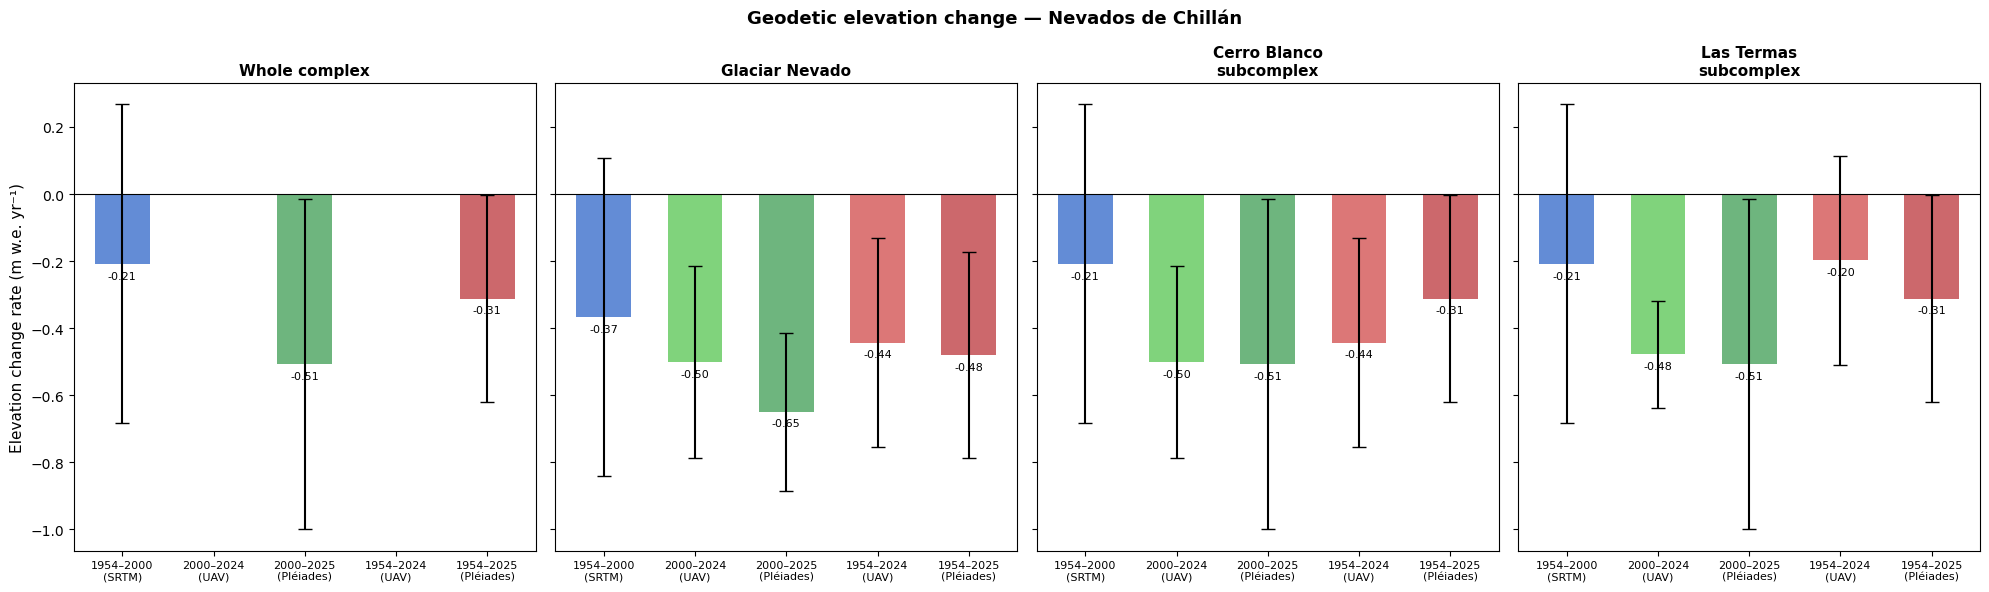

Saved: figures/fig_elevation_change_summary.png


In [55]:
import matplotlib.pyplot as plt
import numpy as np

periods = ['1954–2000\n(SRTM)', '2000–2024\n(UAV)', '2000–2025\n(Pléiades)', '1954–2024\n(UAV)', '1954–2025\n(Pléiades)']

data_by_glacier = {
    'Whole complex': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'complex_mb'),
                  np.nan,
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_mb'),
                  np.nan,
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'complex_sigma'),
                  np.nan,
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_sigma'),
                  np.nan,
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_sigma')],
    },
    'Glaciar Nevado': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'nevado_mb'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','nevado_mb'),
                  get_val('Pleiades_2025_minus_SRTM_2000','nevado_mb'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'nevado_mb'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'nevado_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'nevado_sigma'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','nevado_sigma'),
                  get_val('Pleiades_2025_minus_SRTM_2000','nevado_sigma'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'nevado_sigma'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'nevado_sigma')],
    },
    'Cerro Blanco\nsubcomplex': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'complex_mb'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','complex_mb'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_mb'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'complex_mb'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'complex_sigma'),
                  get_val('CerroBlanco_2024_minus_SRTM_2000','complex_sigma'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_sigma'),
                  get_val('CerroBlanco_2024_minus_IGM_1954', 'complex_sigma'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_sigma')],
    },
    'Las Termas\nsubcomplex': {
        'mb':    [get_val('SRTM_2000_minus_IGM_1954',    'complex_mb'),
                  get_val('LasTermas_2024_minus_SRTM_2000','complex_mb'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_mb'),
                  get_val('LasTermas_2024_minus_IGM_1954', 'complex_mb'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_mb')],
        'sigma': [get_val('SRTM_2000_minus_IGM_1954',    'complex_sigma'),
                  get_val('LasTermas_2024_minus_SRTM_2000','complex_sigma'),
                  get_val('Pleiades_2025_minus_SRTM_2000','complex_sigma'),
                  get_val('LasTermas_2024_minus_IGM_1954', 'complex_sigma'),
                  get_val('Pleiades_2025_minus_IGM_1954', 'complex_sigma')],
    },
}

plt.rcParams.update({'font.family': 'sans-serif'})
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
x     = np.arange(len(periods))
width = 0.6
colors = ['#4878CF', '#6ACC65', '#55A868', '#D65F5F', '#C44E52']

for ax, (glacier, gdata) in zip(axes, data_by_glacier.items()):
    mb    = gdata['mb']
    sigma = gdata['sigma']

    for i, (val, err, col) in enumerate(zip(mb, sigma, colors)):
        if not np.isnan(val):
            ax.bar(x[i], val, width, yerr=err if not np.isnan(err) else 0,
                   capsize=5, color=col, alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(periods, fontsize=8)
    ax.set_title(glacier, fontsize=11, fontweight='bold')

    for i, val in enumerate(mb):
        if not np.isnan(val):
            ax.text(x[i], val - 0.02 if val < 0 else val + 0.02,
                    f'{val:.2f}', ha='center',
                    va='top' if val < 0 else 'bottom', fontsize=8)

axes[0].set_ylabel('Elevation change rate (m w.e. yr⁻¹)', fontsize=11)
fig.suptitle('Geodetic elevation change — Nevados de Chillán',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(figures_folder, 'fig_elevation_change_summary.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', os.path.join(figures_folder, 'fig_elevation_change_summary.png'))

In [ ]:
print("\nNotebook 3 complete.")
print(f"  Results:  {results_folder}/")
print(f"  Figures:  {figures_folder}/")
print(f"  dh maps:  {output_folder}/")


Notebook 3 complete.
  Results:  results/
  Figures:  figures/
  dh maps:  differenced_dems/
